# Climate Change Impact Assessment

## Introduction:

As we saw in the presentation, we can calculate **change factors** to downscale Earth System Model (ESM) data and estimate the impact of climate change on a variable of interest (e.g., temperature, precipitation, humidity, etc.). Now, we will apply the same procedure to the station and variable you have been assigned.

Recall that the change factor method calculates the projected temperature by adding the observed, baseline temperature time series to the change in the temperature from a ESM simulation (typically using monthly ESM data). Thus, the mean ESM bias is removed. In what follows, we will consider the 30-year time period from 1981-2010 as the *baseline* climate.

$$
T_{FUTURE} = T_{OBS\,BASELINE} + \Delta T_{ESM}
$$


To calculate the change factors ($\Delta T_{ESM}$), you will use pre-dowloaded data from the Google Cloud CMIP6 data archive.

We’ll start by comparing the observationally-based baseline surface temperature with the multi-model ESM baseline estimate.

Let's import the relevant python modules we will need.

In [1]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install xarray
!pip install netCDF4
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 72.4 MB/s eta 0:00:00


In [2]:
# import modules
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import xarray as xr
import matplotlib
font = {'size'   : 14}
matplotlib.rc('font', **font)

In [6]:
!git clone https://github.com/kls2177/ISSSTWorkshop2026.git

Cloning into 'ISSSTWorkshop2026'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 39 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (39/39), 2.39 MiB | 11.49 MiB/s, done.
Resolving deltas: 100% (12/12), done.


## 1. Read in Station Data

In this section we will read in the station data. First, upload your station .csv file and revise the cell below to read the name of you station data file.

Note: the the station data has been nicely prepared for you such that there are no missing values.

In [9]:
# revise this cell to read the name of your station data file.
stn_filename = 'ISSSTWorkshop2026/Toronto/Toronto_1981-2010.nc'

Now, read in the data using `xarray` and view the metadata. [Xarray](https://docs.xarray.dev/en/stable/) is a powerful python package for processing multi-dimensional climate and earth system data.

In [10]:
# read in station data
T_STN = xr.open_dataarray(stn_filename)

# display first 5 elements of station data
T_STN.load()

<xarray.DataArray (time: 10957)> Size: 88kB
array([ -8. , -12.5, -18.5, ...,  -1.7,   1.1,   7.6])
Coordinates:
  * time     (time) datetime64[ns] 88kB 1981-01-01 1981-01-02 ... 2010-12-31

There are a few missing values. We will ignore them for this lab.

In [11]:
# Mask NaN values
T_STN = T_STN.where(T_STN != np.nan)

### 1.1. Let's take a look at the station data

Let's make a time series plot of the station data. What do you notice about the data?

Text(0, 0.5, 'Daily Mean Temperature $^{\\circ}$C')

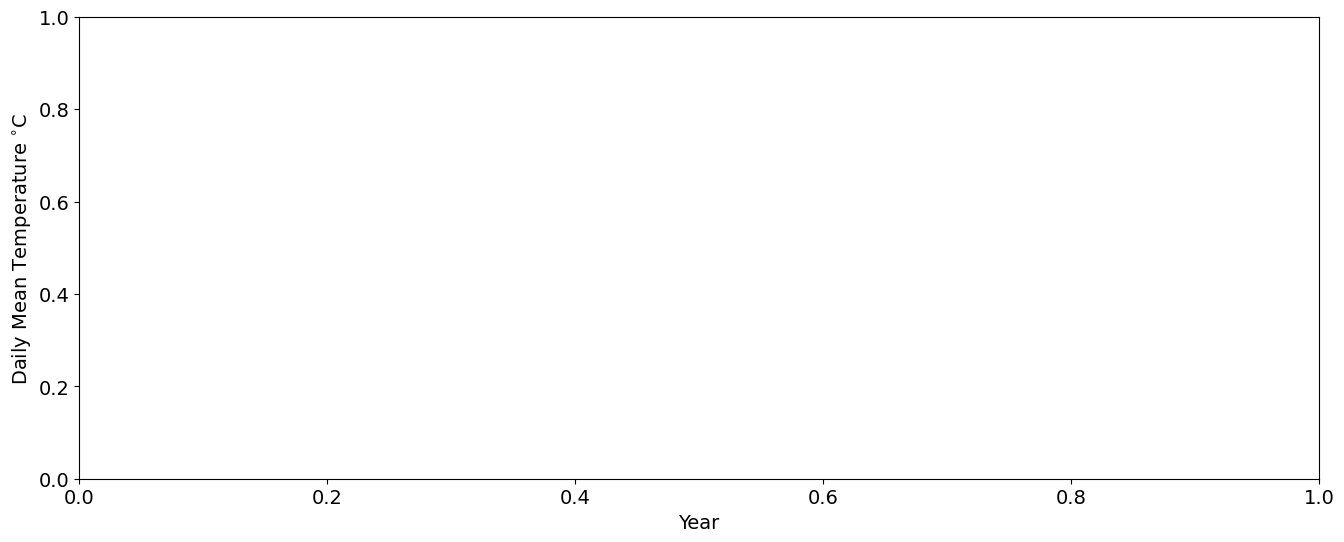

In [12]:
plt.figure(figsize = (16,6))
T_STN.plot(color='gray')
plt.xlabel('Year')
plt.ylabel(r'Daily Mean Temperature $^{\circ}$C')

### 1.2. Let's aggregate our data so that we can compare the station data and the GCM data.

Now, we will compute the 1981-2010 mean and the standard deviation for each month using the `resample` and `grouby` functions.

We will do this in two steps: recall that the station data is at daily resolution, but the ESM data is at monthly resolution. Thus, for the standard deviation, we need to compute the standard deviation of the 30-year baseline using the *monthly mean* station data rather than the daily mean.

#### Step 1:

In [13]:
# step 1: groupby Month and Year and take means - this is how we get the monthly means for each year
T_STN_monthly = T_STN.resample(time="ME").mean()

In [14]:
T_STN_monthly

#### Step 2:

In [15]:
# step 2: now, we groupby Month and then take the mean again and calculate other statistics like standard deviation
T_STN_mean = T_STN_monthly.groupby('time.month').mean()
T_STN_std = T_STN_monthly.groupby('time.month').std()

In [16]:
T_STN_mean

### 1.3. Baseline Seasonal Cycle Data Visualization

Let's visualize this data by plotting a line plot of the baseline (1981-2010 mean) temperature as a function of month. We can add error bars to the line plot showing the standard deviation.

/tmp/ipykernel_1963/4059478205.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


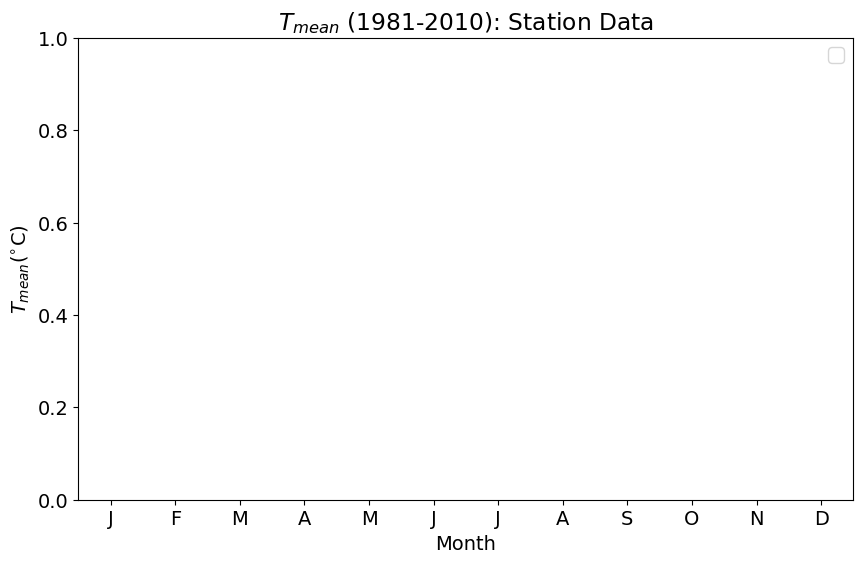

In [17]:
# plot station baseline for tas
plt.figure(figsize=(10,6))
months = np.arange(0.5,12.5,1)

plt.errorbar(months,T_STN_mean, yerr=T_STN_std,color='gray',label='Station Data')
plt.xlim(0,12)
plt.xticks(months,["J","F","M","A","M","J","J","A","S","O","N","D"])
plt.title("$T_{mean}$ (1981-2010): Station Data")
plt.xlabel("Month")
plt.ylabel(r"$T_{mean} (^{\circ}$C)")
plt.legend()

### 1.4. Heating Degree Days

Before we move on to the ESM data, let's calculate a metric that may be of interest to engineers or other stake-holders, *heating degree days* (HDDs). HDDs are the difference between the daily mean surface temperature and the reference temperature of 18 $^{\circ}$C when the daily surface temperature falls below this reference temperature. **They are used as an indirect measure of heating demand in winter.**

So, let's calculate the baseline winter (Jan, Feb, Mar) average number of HDDs.

In [18]:
# create a column consisting of HDDs
base_temp = 18
T_STN_HDD = xr.where(T_STN < base_temp, base_temp - T_STN, 0)

In [19]:
T_STN_HDD

In [20]:
# extract HDDs for winter, sum over the 30-year baseline time period
STN_HDD = T_STN_HDD.groupby('time.season').sum()
STN_HDD

Make a bar plot of the HDDs as a function of season. Use the plotting function `plt.bar()`.

Text(0.5, 1.0, 'HDDs Toronto (1981-2010)')

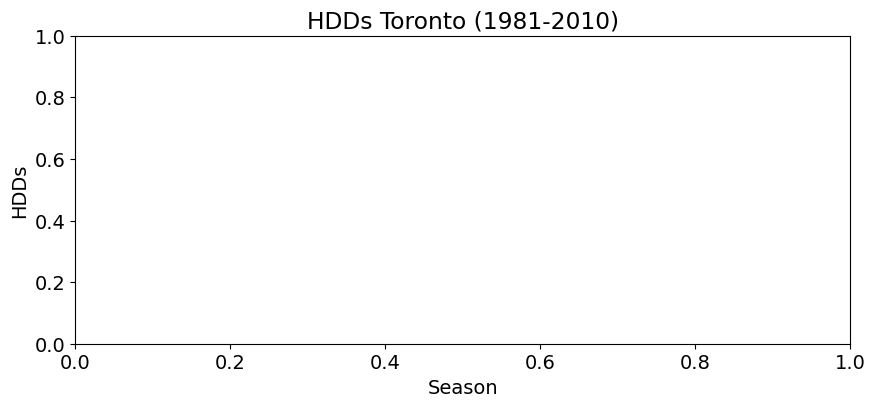

In [21]:
plt.figure(figsize=(10,4))
plt.bar(STN_HDD.season, STN_HDD, color='gray')
plt.xlabel('Season')
plt.ylabel('HDDs')
plt.title('HDDs Toronto (1981-2010)')

What do you notice about how HDDs varies with season? Does this make sense based on how HDDs are defined?


**Repeat the above for *cooling degree days* (CDDs).** CDDs are the difference between the daily mean surface temperature and the reference temperature of 18 $^{\circ}$C when the daily surface temperature is above this reference temperature. They are used as an indirect measure of cooling demand in summer.

## 2. Read in ESM Data

Before we examine the climate change projections, we will calculate the statistics of the baseline climate for 1981-2010 i.e., the climate normals, for the ESM data.

First, we need to read in the ESM data.

In [22]:
# CMIP6 historical data file name
esm_hist_filename = "ISSSTWorkshop2026/Toronto/CMIP6_historical_Toronto.nc"

Now, we will read in the data.

In [23]:
# read file into an xarray dataarray
ESM_hist = xr.open_dataarray(esm_hist_filename)

As above, we can view the first few lines of our dataframe by using the `load()` function.

In [25]:
# take a quick look at the first 5 rows of the data
ESM_hist.load()

What units is the temperature in? Is this the same as the station data? How should you convert the model data to match the station data?

In [26]:
# convert K to degC
ESM_hist = ESM_hist - 273.15

### 2.1 What models do we have?
Let's take a look:

In [27]:
# use the "unique" function to see the unique strings listed for the column "Model"
ESM_hist.model

### 2.2 How many models do we have?

In [28]:
# now find the length of the output from above
len(ESM_hist.model)

### 2.3 Missing Data: Determine which model and for which scenario data are missing.

As we have seen, we have 51 ESMs for the historical time period, but what about the future scenarios? To conduct a clean analysis of future changes, we want to use a consistent ensemble of models.

So, let's load in the ESM data for the future scenarios and take a look.

In [29]:
# CMIP6 SSP data file names
esm_ssp126_filename = "ISSSTWorkshop2026/Toronto/CMIP6_ssp126_Toronto.nc"
esm_ssp245_filename = "ISSSTWorkshop2026/Toronto/CMIP6_ssp245_Toronto.nc"
esm_ssp370_filename = "ISSSTWorkshop2026/Toronto/CMIP6_ssp370_Toronto.nc"
esm_ssp585_filename = "ISSSTWorkshop2026/Toronto/CMIP6_ssp585_Toronto.nc"

In [30]:
# read file into an xarray dataarray
ESM_ssp126 = xr.open_dataarray(esm_ssp126_filename) - 273.15
ESM_ssp245 = xr.open_dataarray(esm_ssp245_filename) - 273.15
ESM_ssp370 = xr.open_dataarray(esm_ssp370_filename) - 273.15
ESM_ssp585 = xr.open_dataarray(esm_ssp585_filename) - 273.15

Let's see how many models we have for each scenario (repeat what we did above):

In [31]:
# print number of models for each scenario
print(len(ESM_ssp126.model), len(ESM_ssp245.model), len(ESM_ssp370.model), len(ESM_ssp585.model))

It looks like we have a different ensemble of models for the future scenario data. Let's use the same ensemble of models for all data sets. We will merge the data so that the models we use represent the *intersection* of the models across the 4 future scenarios. To do this, we use the `merge` function with `join = 'inner'`.

In [32]:
ESM_ssps = xr.merge([ESM_ssp126,ESM_ssp245,ESM_ssp370,ESM_ssp585], join="inner")

In [33]:
ESM_ssps.load()

Now, we have a total of 21 models that are the same across all four future scenarios. Now, let's extract only these models from the historical data.

In [34]:
# extract matching models
ESM_hist = ESM_hist.where(ESM_hist.model == ESM_ssps.model)

In [35]:
ESM_hist

There are only 20 that match. The extra model in the ssps is MPI-ESM1-2-HR. Let's drop this one so that we have a total of 20 models for the historical and all the ssps.

In [36]:
# drop model
ESM_ssps = ESM_ssps.drop_sel(model='MPI-ESM1-2-HR')

## 3. ESM Bias

No ESM is perfect - in fact all models are wrong. Yet, they can be useful and they are the primary tool that we have to examine how the climate may change in the future. So, let's take a look at how well our models do in simulating the baseline climate.

Let's take a look by adding the ESM baseline surface temperature curve to the above plot for the station data.

For today's activity, we will restrict our analysis to the mulit-model mean (the average across all models; MMM). We will compute the MMM across all models.

In [39]:
# compute the mean and standard deviation across all models for each year and month
baseline = ESM_hist.sel(time=slice("1980","2010")).groupby('time.month').mean(dim='time')
baseline_mean = baseline.mean(dim='model')

/tmp/ipykernel_1963/839818249.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_1963/839818249.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


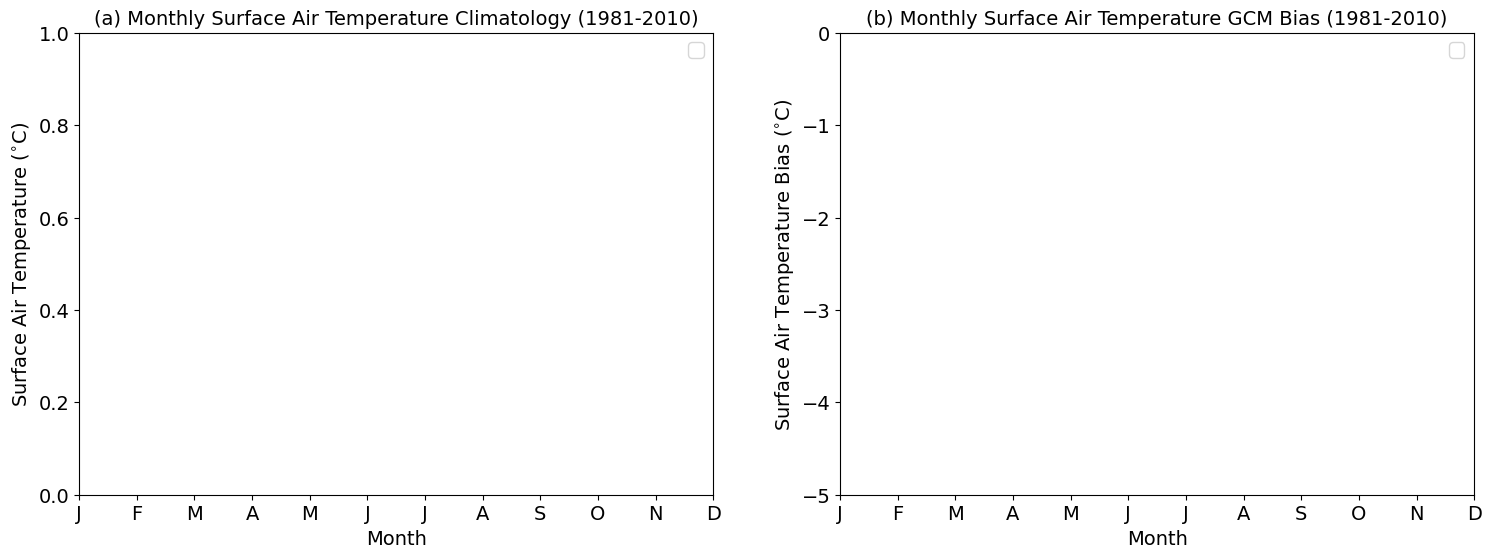

In [37]:
# plot station and ESM baselines for tas
plt.figure(figsize=(18,6))
months = np.arange(0.5,12.5,1)


plt.subplot(1,2,1)
plt.plot(months,baseline_mean,color='r',label='Multi-Model Mean')
plt.plot(months,T_STN_mean,color='b',label='Station Data')

# plot ESM baseline with error bars
plt.xlim(0.5,11.5)
plt.xticks(months,["J","F","M","A","M","J","J","A","S","O","N","D"],fontsize=14)
plt.title("(a) Monthly Surface Air Temperature Climatology (1981-2010)",fontsize=14)
plt.xlabel("Month",fontsize=14)
plt.ylabel(r"Surface Air Temperature ($^{\circ}$C)",fontsize=14)
plt.legend()

plt.subplot(1,2,2)
plt.plot(months,baseline_mean - T_STN_mean,color='k',label='Multi-Model Mean Bias')
plt.xlim(0.5,11.5)
plt.ylim(-5,0)
plt.xticks(months,["J","F","M","A","M","J","J","A","S","O","N","D"],fontsize=14)
plt.title("(b) Monthly Surface Air Temperature GCM Bias (1981-2010)",fontsize=14)
plt.xlabel("Month",fontsize=14)
plt.ylabel(r"Surface Air Temperature Bias ($^{\circ}$C)",fontsize=14)
plt.legend()
plt.savefig("Figure3.png")

How does your multi-model mean (MMM) baseline compare to the station data baseline?

Let's calculate the annual mean difference between the station data baseline and the multi-model mean baseline. This gives us a sense of the multi-mean ESM **bias**.

In [40]:
# to calculate the bias we subtract the station baseline from the ESM baseline
GCM_bias = baseline_mean.mean() - T_STN_mean.mean()
print(np.round(GCM_bias.values,2))

Does the value you get for the bias make sense when you compare it to the plot above? Is your multi-model mean too hot or too cold?

### 3.1. Spread across the models

What we have analyzed above is the bias of the multi-model mean, the average across all 20 models. However, every model is different and has it's own bias. Let's have a look at the spread across the models by just considering the annual mean daily mean temperature.

In [41]:
ESM_hist

In [42]:
# compute the annual mean for the 1981-2010 time period
baseline_ann = ESM_hist.sel(time=slice("1981","2010")).groupby('time.year').mean(dim='time')

In [43]:
baseline_ann

We have 30 years of annual mean data for 20 models. Let's plot all 20 time series together. This is what we call a "spaghetti plot". It's messy but it gives a great visual of the spread across the models. We can also add the station data to the plot, for reference. It's shown in bold black.

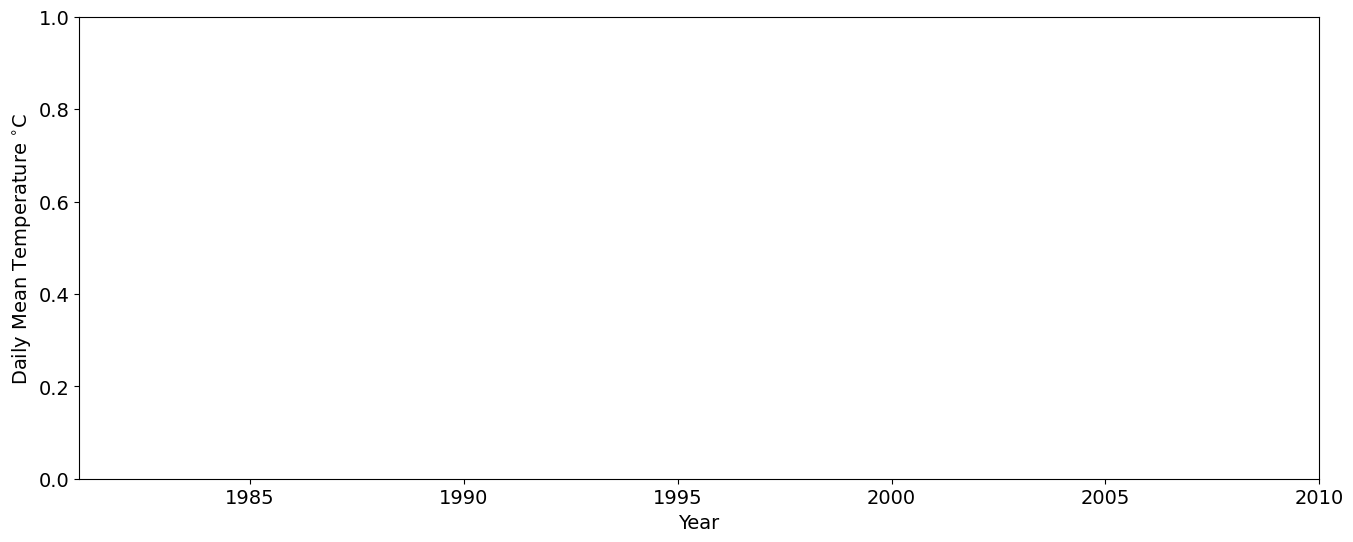

In [44]:
# plot time series of all models
plt.figure(figsize=(16,6))
plt.plot(baseline_ann.year, baseline_ann.T) # we have to flip it around so that the dimensions match
plt.plot(baseline_ann.year, T_STN.groupby('time.year').mean(), color='k', linewidth=5) # we have to flip it around so that the dimensions match
plt.xlim(1981,2010)
plt.xlabel('Year')
plt.ylabel(r'Daily Mean Temperature $^{\circ}$C')
plt.show()

What do you notice about the spread across the models?

## 4. Calculate Multi-model Mean (MMM) ESM Change Factors

Now, we will compute the change factors. Recall that the change factors are $\Delta T_{ESM}$ in the equation below:

$$
T_{FUTURE} = T_{OBS\,BASELINE} + \Delta T_{ESM}
$$

We will compute $\Delta T_{ESM}$ for three, 20-year time periods: 2021-2040, 2051-2070 and 2081-2100 relative to a baseline time period of 1980-2010.

Use the `groupby` function to compute the averages for the 20-year time periods.

In [45]:
# compute multidecadal averages for each month
tm_2030s = ESM_ssps.sel(time=slice("2021","2040")).groupby('time.month').mean(dim='time')
tm_2060s = ESM_ssps.sel(time=slice("2051","2070")).groupby('time.month').mean(dim='time')
tm_2090s = ESM_ssps.sel(time=slice("2081","2100")).groupby('time.month').mean(dim='time')

In [46]:
# compute the change factors
del_2030s = tm_2030s - baseline
del_2060s = tm_2060s - baseline
del_2090s = tm_2090s - baseline

### 4.1. Apply MMM ESM Change Factors

Now, we will calculate our projections using change factors ($\Delta T$'s). The bias in the MMM ESM baseline identified above, will be eliminated using the change factor method.

In [47]:
T_2030s = T_STN.groupby('time.month') + del_2030s
T_2060s = T_STN.groupby('time.month') + del_2060s
T_2090s = T_STN.groupby('time.month') + del_2090s

Now we have downscaled *tas* for each month, scenario and decade!

Let's see what these dataframes look like:

In [48]:
T_2090s.load()

Let's visualize these downscaled projections by plotting the 20-year averages for each time period as a function of month. We will only plot SSP2-4.5 and SSP5-8.5.

/tmp/ipykernel_1963/2231553175.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_1963/2231553175.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


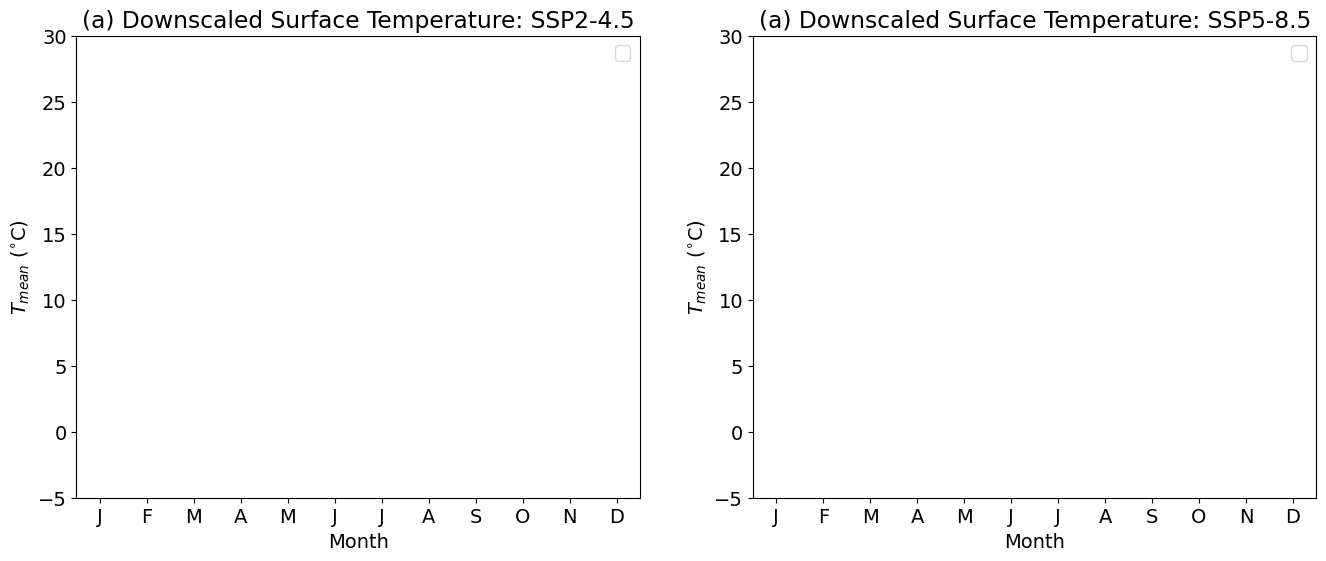

In [49]:
# plot station baseline and downscaled ESM projected 20-year averages for tas
plt.figure(figsize=(16,6))
months = np.arange(0.5,12.5,1)

# SSP245
plt.subplot(1,2,1)
plt.plot(months,T_STN_mean,color='b',label='Station Data')
plt.plot(months,T_2030s.tas_ssp245.groupby('time.month').mean(dim=['time','model']),color='c',label='2030s')
plt.plot(months,T_2060s.tas_ssp245.groupby('time.month').mean(dim=['time','model']),color='orange',label='2060s')
plt.plot(months,T_2090s.tas_ssp245.groupby('time.month').mean(dim=['time','model']),color='r',label='2090s')
plt.xlim(0,12); plt.ylim(-5,30)
plt.xticks(months,["J","F","M","A","M","J","J","A","S","O","N","D"])
plt.title("(a) Downscaled Surface Temperature: SSP2-4.5")
plt.xlabel("Month")
plt.ylabel(r"$T_{mean}$ ($^{\circ}$C)")
plt.legend()

# SSP585
plt.subplot(1,2,2)
plt.plot(months,T_STN_mean,color='b',label='Station Data')
plt.plot(months,T_2030s.tas_ssp585.groupby('time.month').mean(dim=['time','model']),color='c',label='2030s')
plt.plot(months,T_2060s.tas_ssp585.groupby('time.month').mean(dim=['time','model']),color='orange',label='2060s')
plt.plot(months,T_2090s.tas_ssp585.groupby('time.month').mean(dim=['time','model']),color='r',label='2090s')
plt.xlim(0,12); plt.ylim(-5,30)
plt.xticks(months,["J","F","M","A","M","J","J","A","S","O","N","D"])
plt.title("(a) Downscaled Surface Temperature: SSP5-8.5")
plt.xlabel("Month")
plt.ylabel(r"$T_{mean}$ ($^{\circ}$C)")
plt.legend()


## 5. Now We Can Calculate The Variable of Interest: HDDs

For this section, we need the daily downscaled projections. We will compute HDDs in winter by looping over all the months, time periods and scenarios.

In [50]:
T_2030s_HDD = xr.where(T_2030s < base_temp, base_temp - T_2030s, 0)
T_2060s_HDD = xr.where(T_2060s < base_temp, base_temp - T_2060s, 0)
T_2090s_HDD = xr.where(T_2090s < base_temp, base_temp - T_2090s, 0)

In [51]:
# extract HDDs for winter, sum over the 30-year baseline time period and compute average across all models
T_2030s_HDD_mean = T_2030s_HDD.groupby('time.season').sum(dim='time').mean(dim='model').sel(season='DJF')
T_2060s_HDD_mean = T_2060s_HDD.groupby('time.season').sum(dim='time').mean(dim='model').sel(season='DJF')
T_2090s_HDD_mean = T_2090s_HDD.groupby('time.season').sum(dim='time').mean(dim='model').sel(season='DJF')

We now have the projected average number of HDDs per season for each tri-decade and scenario.

Let's make a bar plot to see how the HDDs change over time and across scenarios.

In [52]:
# organize data to make a bar plot.
DD_STN = np.hstack((STN_HDD.sel(season='DJF'),0,0,0))
DD_SSP245 = np.hstack((0,T_2030s_HDD_mean.tas_ssp245,T_2060s_HDD_mean.tas_ssp245,T_2090s_HDD_mean.tas_ssp245))
DD_SSP585 = np.hstack((0,T_2030s_HDD_mean.tas_ssp585,T_2060s_HDD_mean.tas_ssp585,T_2090s_HDD_mean.tas_ssp585))

[Text(0.44999999999999996, 0, '1990s'),
 Text(1.45, 0, '2030s'),
 Text(2.45, 0, '2060s'),
 Text(3.45, 0, '2090s')]

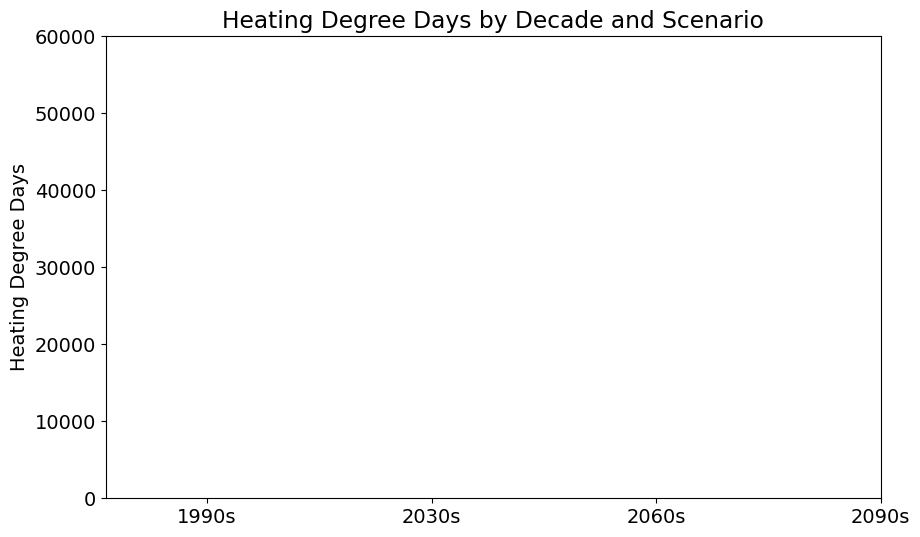

In [54]:
# make bar plot
N = 4              # number of decades
ind = np.arange(N) # the x locations for the groups
width = 0.3        # the width of the bars

fig, ax = plt.subplots(figsize=(10,6))
rects0 = ax.bar(ind, DD_STN, width,color='k')
rects1 = ax.bar(ind + width , DD_SSP245, width, color='lightblue')
rects2 = ax.bar(ind + 2*width, DD_SSP585, width, color='salmon')

# add some text for labels, title and axes ticks
ax.set_ylabel('Heating Degree Days')
ax.set_title('Heating Degree Days by Decade and Scenario')
ax.set_ylim(0,60000)
ax.set_xticks(ind + 1.5*width)
ax.set_xticklabels(('1990s','2030s', '2060s','2090s'))

ax.legend((rects0[0], rects1[0], rects2[0],), ('STN','SSP245', 'SSP585'))

**Repeat the plot for the shoulder seasons (spring and autumn).** How do these change as the climate changes?

**Repeat the above for CDDs in summer and the shoulder seasons.**